# Why borrowing Code Llama's rope_theta scrambles Llama-2's positions

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## Pairs of numbers, turned by position

In [1]:
import numpy as np

def rope(x, pos, base=10_000.0):
    """Rotate each consecutive pair (x[2i], x[2i+1]) by angle pos * theta_i."""
    d = x.shape[-1]
    theta = base ** (-np.arange(0, d, 2) / d)       # d/2 frequencies
    z = x[..., 0::2] + 1j * x[..., 1::2]            # pairs as complex numbers
    z = z * np.exp(1j * pos * theta)                # rotate
    out = np.empty_like(x)
    out[..., 0::2], out[..., 1::2] = z.real, z.imag
    return out

## Why only the distance survives

In [2]:
rng = np.random.default_rng(0)
q, k = rng.standard_normal(128), rng.standard_normal(128)
for m, n in [(5, 12), (1005, 1012), (90_000, 90_007)]:
    print(m, n, round(rope(q, m) @ rope(k, n), 10))

lam = lambda b: 2 * np.pi * b ** (np.arange(0, 128, 2) / 128)   # wavelengths
idx = [0, 15, 31, 45, 63]
for b in (1e4, 1e6):
    print(b, [f"{w:,.1f}" for w in lam(b)[idx]])
print((lam(1e4) > 4096).sum(), round(np.degrees(2 * np.pi * 4096 / lam(1e4)[-1])))

5 12 1.3349654804
1005 1012 1.3349654804
90000 90007 1.3349654803
10000.0 ['6.3', '54.4', '544.1', '4,080.2', '54,410.1']
1000000.0 ['6.3', '160.1', '5,063.3', '103,975.2', '5,063,255.8']
18 27


## What changing the base does

In [3]:
th = lambda b: b ** (-np.arange(0, 128, 2) / 128)
t_old, t_new = th(1e4), th(1e6)
for D in (4, 16, 256, 1024, 4096):
    gap = np.abs(np.angle(np.exp(1j * D * (t_old - t_new))))   # wrapped, 0..pi
    print(f"offset {D:5,d}: {(gap > np.pi / 4).sum():2d} of 64 pairs off by > 45 deg, "
          f"mean gap {np.degrees(gap.mean()):4.1f} deg")
shift = np.degrees(t_old - t_new)                                # per token of offset
print(shift.argmax() + 1, round(shift.max(), 1), round(4096 * t_new[45] / t_old[45]))
print(round(1e4 * 8 ** (128 / 126), -2))                         # NTK base, used below
print([float(round((0.1 * np.log(s) + 1) ** 2, 2)) for s in (8, 16, 32)])  # YaRN, below

offset     4:  0 of 64 pairs off by > 45 deg, mean gap  8.3 deg
offset    16: 18 of 64 pairs off by > 45 deg, mean gap 33.1 deg
offset   256: 30 of 64 pairs off by > 45 deg, mean gap 59.2 deg
offset 1,024: 40 of 64 pairs off by > 45 deg, mean gap 72.7 deg
offset 4,096: 44 of 64 pairs off by > 45 deg, mean gap 81.8 deg
7 8.5 161
82700.0
[1.46, 1.63, 1.81]


## The figure

In [4]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

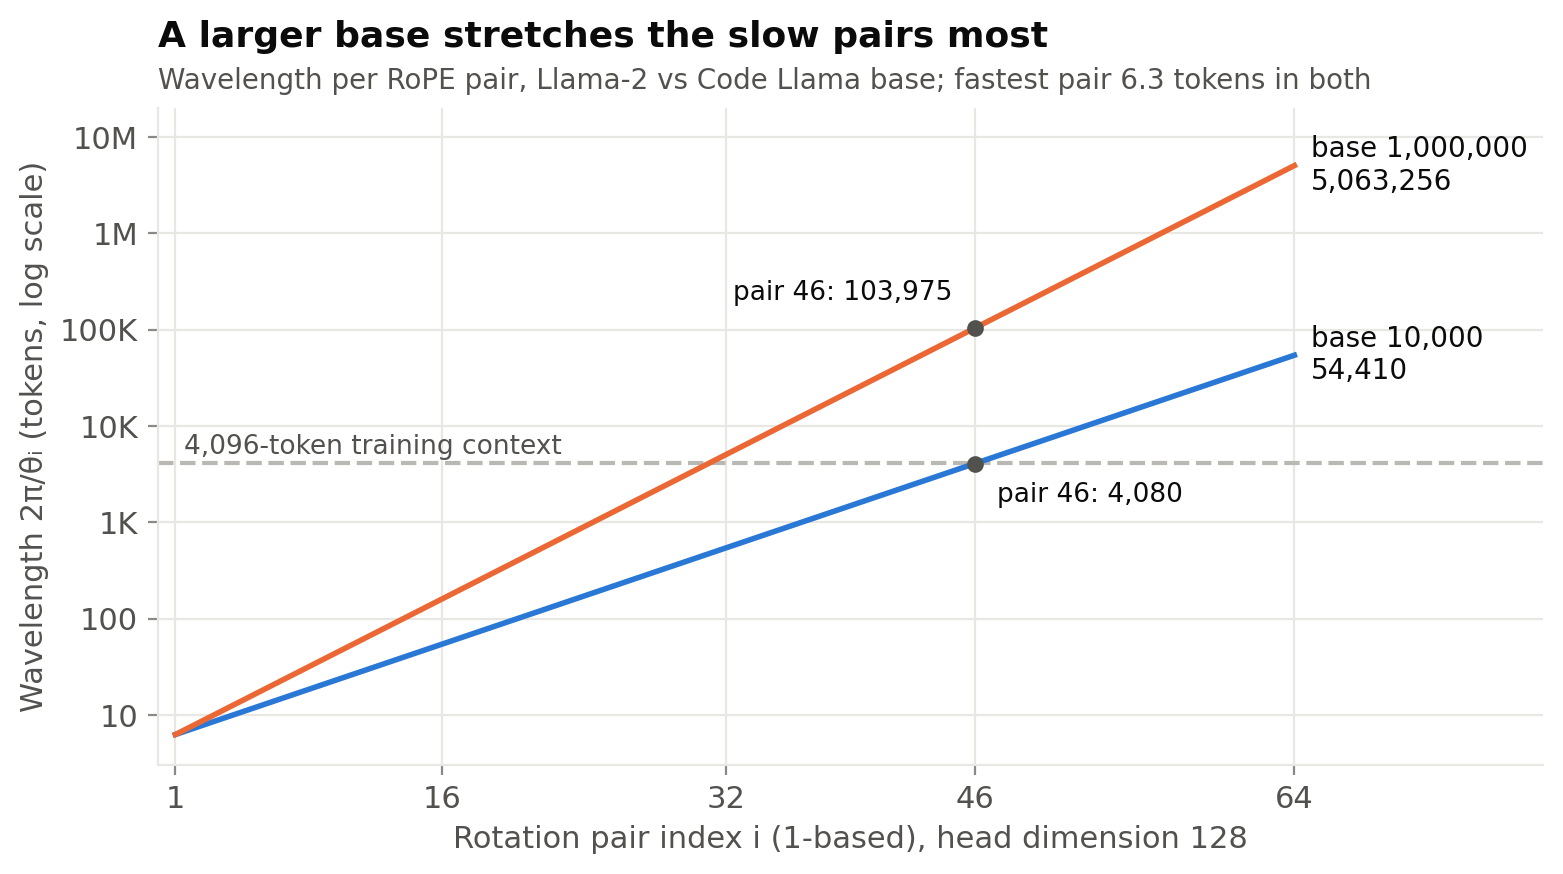

In [5]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    d = 128
    lam = lambda b: 2 * np.pi * b ** (np.arange(0, d, 2) / d)   # as in the article
    pair = np.arange(1, d // 2 + 1)
    lo, hi = lam(1e4), lam(1e6)
    print(round(lo[45], 1), round(hi[45], 1), round(lo[-1], 1), round(hi[-1], 1))

    f, ax = fig()
    ax.set_yscale("log")
    ax.axhline(4096, color=NEUTRAL, lw=1.5, ls="--")
    ax.text(1.5, 4096 * 1.25, "4,096-token training context", color=INK_2, fontsize=9.5)
    ax.plot(pair, lo, color=S1)
    ax.plot(pair, hi, color=S2)
    label_end(ax, 64, hi[-1], "base 1,000,000\n5,063,256", S2, dx=6)
    label_end(ax, 64, lo[-1], "base 10,000\n54,410", S1, dx=6)
    ax.plot([46, 46], [lo[45], hi[45]], color=INK_2, lw=0, marker="o", ms=5)
    ax.annotate("pair 46: 4,080", (46, lo[45]), xytext=(8, -14), textcoords="offset points",
                color=INK, fontsize=9.5)
    ax.annotate("pair 46: 103,975", (46, hi[45]), xytext=(-8, 10), textcoords="offset points",
                color=INK, fontsize=9.5, ha="right")
    ax.set_xlim(0, 78); ax.set_xticks([1, 16, 32, 46, 64])
    ax.set_ylim(3, 2e7)
    ax.set_yticks([10, 100, 1e3, 1e4, 1e5, 1e6, 1e7], ["10", "100", "1K", "10K", "100K", "1M", "10M"])
    ax.set_yticks([], minor=True)
    ax.set_xlabel("Rotation pair index i (1-based), head dimension 128")
    ax.set_ylabel("Wavelength 2π/θᵢ (tokens, log scale)")
    ax.set_title("A larger base stretches the slow pairs most")
    subtitle(ax, "Wavelength per RoPE pair, Llama-2 vs Code Llama base; fastest pair 6.3 tokens in both")
    path = pathlib.Path(__file__).parent / "07-rope-wavelengths.png"
    save(f, path)
import matplotlib.pyplot as plt
plt.show()